# 04 · Iteraciones del MLP

Protocolo fijo (notebook 02): `KFold(5)` × 3 semillas sobre `train_dev`, RMSE **out-of-fold
agrupado**. El test interno no se toca aquí.

- **Umbral de mejora real:** la variación entre semillas medida en el notebook 02. Una
  diferencia menor es ruido de partición.
- **Métrica de sobreajuste:** `gap = RMSE_val − RMSE_train`. Una iteración que baja el RMSE de
  validación pero dispara el gap se marca como sospechosa, no como mejora.
- **Objetivo:** bajar del mejor baseline del notebook 03.

**Estructura:** se parte de un MLP mínimo (it00) para dejar constancia del punto de partida,
se define una **referencia regularizada** (it01) y a partir de ahí se hacen ablaciones y barridos
*alrededor* de ella. Barrer la arquitectura sin regularización activa sesgaría la búsqueda hacia
redes diminutas —las grandes memorizan— y luego la regularización ya no podría recuperar la
capacidad perdida.

In [1]:
import json, sys, time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sys.path.insert(0, str(Path.cwd().parent))
from src.data import ROOT, load_raw, split_xy
from src.experiments import Bitacora, cv_multiseed
from src.model import ModelConfig
from src.preprocessing import PreprocessConfig

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight"})
FIGURES = ROOT / "reports" / "figures"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEMILLAS = (42, 43, 44)

# Umbral y objetivo se leen de los notebooks anteriores en vez de codificarse a mano
BASELINES = pd.read_csv(ROOT / "reports" / "baselines.csv")
OBJETIVO = float(BASELINES.loc[~BASELINES["modelo"].str.contains("Dummy"), "RMSE"].min())
MEJOR_BASELINE = BASELINES.loc[BASELINES["RMSE"] == OBJETIVO, "modelo"].iloc[0]

df = load_raw(ROOT / "data" / "raw" / "train.csv")
X, y = split_xy(df)
split = json.loads((ROOT / "data" / "processed" / "split.json").read_text())
mask_dev = df["Id"].isin(split["id_dev"]).to_numpy()
X_dev = X[mask_dev].reset_index(drop=True)
y_dev = y[mask_dev].reset_index(drop=True)
ids_dev = df.loc[mask_dev, "Id"].reset_index(drop=True)

UMBRAL = json.loads((ROOT / "data" / "processed" / "split.json").read_text()).get(
    "umbral_mejora", 600)

bitacora = Bitacora(reset=True)   # esta corrida es la única fuente de la bitácora
resultados = {}

def correr(id, desc, pre_cfg, mlp_cfg, excluir=None):
    r = cv_multiseed(X_dev, y_dev, pre_cfg, mlp_cfg, semillas=SEMILLAS, n_splits=5,
                     stratify=False, id=id, descripcion=desc, device=DEVICE,
                     excluir_de_train=excluir)
    bitacora.añadir(r); resultados[id] = r
    print(f"{id:<8} {desc:<38} val {r.val_rmse:>8,.0f} ±{r.val_std:>5,.0f} "
          f"| train {r.train_rmse:>7,.0f} | gap {r.gap:>7,.0f} ({r.gap_ratio:>5.0%}) "
          f"| {r.segundos:>4.0f}s")
    return r

print(f"train_dev {X_dev.shape} | device {DEVICE}")
print(f"Objetivo a batir: {MEJOR_BASELINE} = {OBJETIVO:,.0f} USD | umbral de mejora {UMBRAL:,.0f} USD")

train_dev (992, 79) | device cuda
Objetivo a batir: GradientBoosting (500) = 31,877 USD | umbral de mejora 3,074 USD


## A · Punto de partida y referencia

In [2]:
PRE_MIN = PreprocessConfig(derived=False, log_skewed=False, drop_quasi_constant=False,
                           rare_min_count=0)
PRE_REF = PreprocessConfig()   # todas las decisiones del EDA activadas

# it00: lo más simple posible — una capa, sin regularización, target en USD
correr("it00", "MLP mínimo sin regularizar",
       PRE_MIN, ModelConfig(hidden=(64,), dropout=0.0, batchnorm=False, weight_decay=0.0,
                            log_target=False, max_epochs=250, patience=35))

# it01: referencia — regularización estándar y preprocesamiento completo del EDA
MLP_REF = ModelConfig(hidden=(256, 128), dropout=0.2, batchnorm=True, weight_decay=1e-4,
                      log_target=True, max_epochs=250, patience=35)
correr("it01", "REFERENCIA: bn + dropout .2 + wd 1e-4", PRE_REF, MLP_REF)

it00     MLP mínimo sin regularizar             val   34,564 ±  649 | train  22,738 | gap  11,825 (  52%) |   11s


it01     REFERENCIA: bn + dropout .2 + wd 1e-4  val   33,624 ±4,125 | train  15,315 | gap  18,308 ( 120%) |   22s


ResultadoCV(id='it01', descripcion='REFERENCIA: bn + dropout .2 + wd 1e-4', train_rmse=15315.455198965481, val_rmse=33623.75132527255, val_std=4124.707267621428, gap=18308.29612630707, gap_ratio=1.1954131227874798, epocas_media=35.46666666666666, segundos=22.023302946989133, n_features=202, pre_config={'derived': True, 'log_skewed': True, 'skew_threshold': 0.75, 'drop_quasi_constant': True, 'rare_min_count': 5, 'scale': True}, model_config={'hidden': (256, 128), 'dropout': 0.2, 'batchnorm': True, 'activation': 'relu', 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'max_epochs': 250, 'patience': 35, 'scheduler': 'plateau', 'loss': 'mse', 'log_target': True, 'seed': 42}, fold_val_rmse=[27019.108544854862, 31363.668825891084, 28585.787405274972, 32414.997959842993, 19830.226682253968, 34698.165049825984, 19302.82518557583, 18784.29107630791, 22010.600945547227, 69895.95034660706, 59361.060360715506, 20460.325207538124, 20280.559543927106, 22951.31688945561, 32514.904111178093], hi

### Ablaciones sobre la referencia — ¿qué aporta cada componente?

In [3]:
ablaciones = {
    "it02": ("sin batchnorm", {"batchnorm": False}, None),
    "it03": ("sin dropout", {"dropout": 0.0}, None),
    "it04": ("sin weight decay", {"weight_decay": 0.0}, None),
    "it05": ("sin log1p en el target", {"log_target": False}, None),
    "it06": ("sin ninguna regularización", {"batchnorm": False, "dropout": 0.0,
                                            "weight_decay": 0.0}, None),
    "it07": ("preprocesamiento mínimo", {}, PRE_MIN),
}
for id, (desc, cambio, pc) in ablaciones.items():
    correr(id, desc, pc or PRE_REF, ModelConfig(**{**MLP_REF.to_dict(), **cambio}))

it02     sin batchnorm                          val   37,230 ±7,613 | train  15,637 | gap  21,593 ( 138%) |   17s


it03     sin dropout                            val   35,249 ±4,374 | train  16,460 | gap  18,789 ( 114%) |   17s


it04     sin weight decay                       val   33,569 ±4,215 | train  15,343 | gap  18,226 ( 119%) |   24s


it05     sin log1p en el target                 val   33,225 ±2,947 | train  13,458 | gap  19,767 ( 147%) |   23s


it06     sin ninguna regularización             val   40,433 ±10,117 | train  16,007 | gap  24,426 ( 153%) |   13s


it07     preprocesamiento mínimo                val   36,954 ±1,442 | train  18,322 | gap  18,632 ( 102%) |   21s


In [4]:
ref = resultados["it01"].val_rmse
print(f"Referencia it01: {ref:,.0f} USD\n")
print(f"{'':8}{'ablación':<32}{'Δ RMSE':>10}{'Δ gap':>10}  aporte")
print("-" * 74)
for id, (desc, _, _) in ablaciones.items():
    d = resultados[id].val_rmse - ref
    dg = resultados[id].gap - resultados["it01"].gap
    v = "necesario" if d > UMBRAL else ("perjudica" if d < -UMBRAL else "indiferente")
    print(f"{id:<8}{desc:<32}{d:>+10,.0f}{dg:>+10,.0f}  {v}")

Referencia it01: 33,624 USD

        ablación                            Δ RMSE     Δ gap  aporte
--------------------------------------------------------------------------
it02    sin batchnorm                       +3,606    +3,284  necesario
it03    sin dropout                         +1,625      +481  indiferente
it04    sin weight decay                       -55       -82  indiferente
it05    sin log1p en el target                -399    +1,459  indiferente
it06    sin ninguna regularización          +6,809    +6,117  necesario
it07    preprocesamiento mínimo             +3,331      +324  necesario


## B · Arquitectura (con la regularización de la referencia activa)

In [5]:
arqs = {"it08": (64,), "it09": (128,), "it10": (128, 64), "it11": (512, 256),
        "it12": (256, 128, 64), "it13": (128, 64, 32)}
for id, h in arqs.items():
    correr(id, f"hidden={h}", PRE_REF, ModelConfig(**{**MLP_REF.to_dict(), "hidden": h}))

it08     hidden=(64,)                           val   32,349 ±5,087 | train  17,196 | gap  15,153 (  88%) |   21s


it09     hidden=(128,)                          val   32,351 ±5,709 | train  13,649 | gap  18,702 ( 137%) |   23s


it10     hidden=(128, 64)                       val   32,096 ±3,372 | train  18,028 | gap  14,068 (  78%) |   19s


it11     hidden=(512, 256)                      val   32,846 ±3,127 | train  15,545 | gap  17,301 ( 111%) |   23s


it12     hidden=(256, 128, 64)                  val   32,194 ±3,513 | train  17,190 | gap  15,004 (  87%) |   22s


it13     hidden=(128, 64, 32)                   val   32,378 ±4,703 | train  19,049 | gap  13,329 (  70%) |   26s


In [6]:
cand_arq = {"it01": (256, 128), **arqs}
mejor_arq = min(cand_arq, key=lambda i: resultados[i].val_rmse)
HIDDEN = cand_arq[mejor_arq]
print(f"Mejor arquitectura: {mejor_arq} → hidden={HIDDEN} "
      f"({resultados[mejor_arq].val_rmse:,.0f} USD)\n")
print(f"{'':8}{'arquitectura':<22}{'pesos':>10}{'val':>10}{'gap':>10}")
print("-" * 62)
for i, h in sorted(cand_arq.items(), key=lambda kv: resultados[kv[0]].val_rmse):
    dims = (resultados[i].n_features,) + h + (1,)
    n_par = sum(a * b + b for a, b in zip(dims, dims[1:]))
    print(f"{i:<8}{str(h):<22}{n_par:>10,}{resultados[i].val_rmse:>10,.0f}"
          f"{resultados[i].gap:>10,.0f}")

Mejor arquitectura: it10 → hidden=(128, 64) (32,096 USD)

        arquitectura               pesos       val       gap
--------------------------------------------------------------
it10    (128, 64)                 34,305    32,096    14,068
it12    (256, 128, 64)            93,185    32,194    15,004
it08    (64,)                     13,057    32,349    15,153
it09    (128,)                    26,113    32,351    18,702
it13    (128, 64, 32)             36,353    32,378    13,329
it11    (512, 256)               235,521    32,846    17,301
it01    (256, 128)                84,993    33,624    18,308


## C · Intensidad de la regularización

In [7]:
MLP_C = ModelConfig(**{**MLP_REF.to_dict(), "hidden": HIDDEN})
for id, d in {"it14": 0.1, "it15": 0.35, "it16": 0.5, "it17": 0.65}.items():
    correr(id, f"dropout={d}", PRE_REF, ModelConfig(**{**MLP_C.to_dict(), "dropout": d}))

it14     dropout=0.1                            val   32,192 ±3,601 | train  13,545 | gap  18,647 ( 138%) |   23s


it15     dropout=0.35                           val   31,827 ±3,481 | train  21,334 | gap  10,493 (  49%) |   24s


it16     dropout=0.5                            val   34,577 ±1,196 | train  25,363 | gap   9,214 (  36%) |   21s


it17     dropout=0.65                           val   35,288 ±  988 | train  26,763 | gap   8,526 (  32%) |   26s


In [8]:
cand_do = {"it01" if mejor_arq == "it01" else mejor_arq: 0.2,
           "it14": 0.1, "it15": 0.35, "it16": 0.5, "it17": 0.65}
mejor_do = min(cand_do, key=lambda i: resultados[i].val_rmse)
DROPOUT = cand_do[mejor_do]
print(f"Mejor dropout: {DROPOUT} ({resultados[mejor_do].val_rmse:,.0f} USD)")

MLP_D = ModelConfig(**{**MLP_C.to_dict(), "dropout": DROPOUT})
for id, wd in {"it18": 1e-5, "it19": 1e-3, "it20": 1e-2}.items():
    correr(id, f"weight_decay={wd:g}", PRE_REF,
           ModelConfig(**{**MLP_D.to_dict(), "weight_decay": wd}))

Mejor dropout: 0.35 (31,827 USD)


it18     weight_decay=1e-05                     val   31,905 ±3,285 | train  21,388 | gap  10,518 (  49%) |   22s


it19     weight_decay=0.001                     val   31,975 ±3,371 | train  22,196 | gap   9,779 (  44%) |   22s


it20     weight_decay=0.01                      val   31,766 ±3,546 | train  21,548 | gap  10,218 (  47%) |   22s


Mejor weight_decay: 0.01 (31,766 USD)


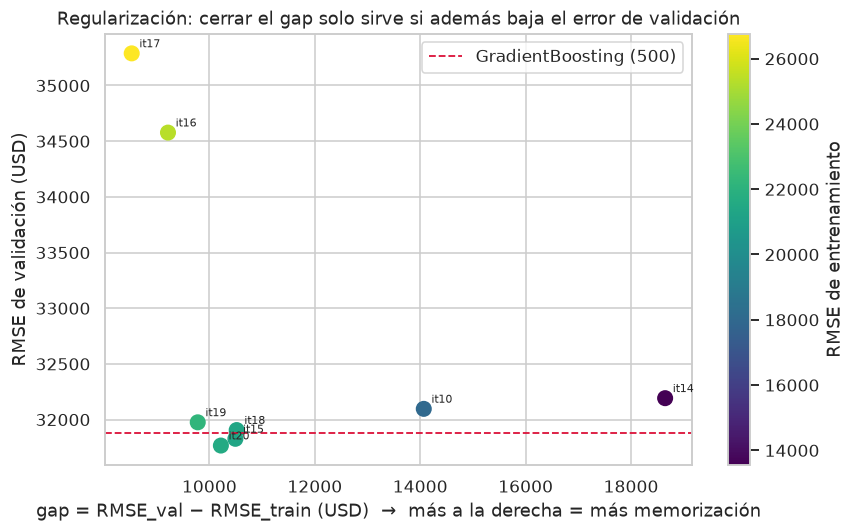

In [9]:
cand_wd = {mejor_do: 1e-4, "it18": 1e-5, "it19": 1e-3, "it20": 1e-2}
mejor_wd_id = min(cand_wd, key=lambda i: resultados[i].val_rmse)
WD = cand_wd[mejor_wd_id]
print(f"Mejor weight_decay: {WD:g} ({resultados[mejor_wd_id].val_rmse:,.0f} USD)")

ids_reg = list(dict.fromkeys(list(cand_do) + list(cand_wd)))
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter([resultados[i].gap for i in ids_reg],
                [resultados[i].val_rmse for i in ids_reg],
                c=[resultados[i].train_rmse for i in ids_reg], cmap="viridis", s=90)
for i in ids_reg:
    ax.annotate(i, (resultados[i].gap, resultados[i].val_rmse), fontsize=7.5,
                xytext=(5, 4), textcoords="offset points")
ax.axhline(OBJETIVO, ls="--", color="crimson", lw=1.2, label=MEJOR_BASELINE)
ax.set_xlabel("gap = RMSE_val − RMSE_train (USD)  →  más a la derecha = más memorización")
ax.set_ylabel("RMSE de validación (USD)")
ax.set_title("Regularización: cerrar el gap solo sirve si además baja el error de validación")
plt.colorbar(sc, label="RMSE de entrenamiento"); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "15_regularizacion.png"); plt.show()

## D · Preprocesamiento (hipótesis del EDA)

In [10]:
MLP_E = ModelConfig(**{**MLP_D.to_dict(), "weight_decay": WD})
variantes = {
    "it21": ("sin features derivadas", PreprocessConfig(derived=False)),
    "it22": ("sin log1p a sesgadas", PreprocessConfig(log_skewed=False)),
    "it23": ("sin agrupar categorías raras", PreprocessConfig(rare_min_count=0)),
    "it24": ("conservando cuasi-constantes", PreprocessConfig(drop_quasi_constant=False)),
    "it25": ("agrupación de raras más agresiva", PreprocessConfig(rare_min_count=15)),
}
for id, (desc, pc) in variantes.items():
    correr(id, desc, pc, MLP_E)

it21     sin features derivadas                 val   34,052 ±2,220 | train  20,673 | gap  13,380 (  65%) |   25s


it22     sin log1p a sesgadas                   val   32,514 ±4,702 | train  21,334 | gap  11,180 (  52%) |   22s


it23     sin agrupar categorías raras           val   31,195 ±2,547 | train  21,206 | gap   9,989 (  47%) |   24s


it24     conservando cuasi-constantes           val   35,950 ±1,553 | train  26,262 | gap   9,688 (  37%) |   18s


it25     agrupación de raras más agresiva       val   31,779 ±3,394 | train  24,188 | gap   7,591 (  31%) |   21s


In [11]:
base_pre = resultados[mejor_wd_id].val_rmse
print(f"Preprocesamiento completo (referencia): {base_pre:,.0f} USD\n")
print(f"{'':8}{'variante':<38}{'Δ RMSE':>10}  veredicto")
print("-" * 74)
for id, (desc, _) in variantes.items():
    d = resultados[id].val_rmse - base_pre
    v = "quitarlo mejora" if d < -UMBRAL else ("hace falta" if d > UMBRAL else "indiferente")
    print(f"{id:<8}{desc:<38}{d:>+10,.0f}  {v}")

cand_pre = {mejor_wd_id: PreprocessConfig(), **{k: v[1] for k, v in variantes.items()}}
MEJOR_PRE_ID = min(cand_pre, key=lambda i: resultados[i].val_rmse)
PRE_F = cand_pre[MEJOR_PRE_ID]
print(f"\nPreprocesamiento arrastrado: {MEJOR_PRE_ID} ({resultados[MEJOR_PRE_ID].val_rmse:,.0f} USD)")

Preprocesamiento completo (referencia): 31,766 USD

        variante                                  Δ RMSE  veredicto
--------------------------------------------------------------------------
it21    sin features derivadas                    +2,286  indiferente
it22    sin log1p a sesgadas                        +748  indiferente
it23    sin agrupar categorías raras                -571  indiferente
it24    conservando cuasi-constantes              +4,184  hace falta
it25    agrupación de raras más agresiva             +13  indiferente

Preprocesamiento arrastrado: it23 (31,195 USD)


## E · Outliers: A/B de los puntos influyentes

In [12]:
# Se quitan SOLO del entrenamiento; la validación queda íntegra. Sacarlos también de
# validación bajaría el RMSE sin que el modelo mejore, y el dataset de la competencia
# sí va a contener casos así.
contrato = json.loads((ROOT / "data" / "processed" / "column_types.json").read_text())
ids_influyentes = contrato["ids_influyentes"]
mask_infl = ids_dev.isin(ids_influyentes).to_numpy()
mask_partial = ((X_dev["SaleCondition"] == "Partial") & (X_dev["GrLivArea"] > 3000)).to_numpy()
mask_caras = (y_dev > y_dev.quantile(0.995)).to_numpy()
print(f"Puntos influyentes en train_dev : {mask_infl.sum()} (de {ids_influyentes})")
print(f"Partial de >3000 sqft           : {mask_partial.sum()}")
print(f"Precio por encima del p99.5     : {mask_caras.sum()}\n")

correr("it26", "sin puntos influyentes", PRE_F, MLP_E, excluir=mask_infl)
correr("it27", "sin Partial de >3000 sqft", PRE_F, MLP_E, excluir=mask_partial)
correr("it28", "sin influyentes ni Partial grandes", PRE_F, MLP_E,
       excluir=(mask_infl | mask_partial))
correr("it29", "sin el 0.5 % más caro", PRE_F, MLP_E, excluir=mask_caras)

Puntos influyentes en train_dev : 2 (de [524, 1299])
Partial de >3000 sqft           : 3
Precio por encima del p99.5     : 5



it26     sin puntos influyentes                 val   32,073 ±2,718 | train  20,667 | gap  11,406 (  55%) |   19s


it27     sin Partial de >3000 sqft              val   31,948 ±2,575 | train  19,655 | gap  12,292 (  63%) |   23s


it28     sin influyentes ni Partial grandes     val   31,948 ±2,575 | train  19,655 | gap  12,292 (  63%) |   24s


it29     sin el 0.5 % más caro                  val   32,127 ±3,410 | train  18,326 | gap  13,801 (  75%) |   22s


ResultadoCV(id='it29', descripcion='sin el 0.5 % más caro', train_rmse=18325.9256443475, val_rmse=32127.349355327908, val_std=3410.1379943384322, gap=13801.423710980409, gap_ratio=0.7531092278134043, epocas_media=34.666666666666664, segundos=21.741659189996426, n_features=217, pre_config={'derived': True, 'log_skewed': True, 'skew_threshold': 0.75, 'drop_quasi_constant': True, 'rare_min_count': 0, 'scale': True}, model_config={'hidden': (128, 64), 'dropout': 0.35, 'batchnorm': True, 'activation': 'relu', 'lr': 0.001, 'weight_decay': 0.01, 'batch_size': 64, 'max_epochs': 250, 'patience': 35, 'scheduler': 'plateau', 'loss': 'mse', 'log_target': True, 'seed': 42}, fold_val_rmse=[29337.443390635315, 31272.2124927051, 25627.547568860024, 28707.3738987485, 20177.65365507676, 35285.12295412891, 18901.77860580713, 21041.41272103206, 21385.28656177908, 58474.45795967931, 57580.1967901738, 22533.622429491184, 22803.824575018825, 26213.14120314279, 31195.83634715764], historias=[Historia(train_rm

In [13]:
print(f"{'':8}{'exclusión':<38}{'Δ vs. sin excluir':>18}  veredicto")
print("-" * 76)
for id in ["it26", "it27", "it28", "it29"]:
    d = resultados[id].val_rmse - resultados[MEJOR_PRE_ID].val_rmse
    v = "mejora real" if d < -UMBRAL else ("empeora" if d > UMBRAL else "dentro del ruido")
    print(f"{id:<8}{resultados[id].descripcion:<38}{d:>+18,.0f}  {v}")

cand_out = {MEJOR_PRE_ID: None, "it26": mask_infl, "it27": mask_partial,
            "it28": mask_infl | mask_partial, "it29": mask_caras}
MEJOR_OUT_ID = min(cand_out, key=lambda i: resultados[i].val_rmse)
EXCLUIR = cand_out[MEJOR_OUT_ID]
print(f"\nExclusión arrastrada: {MEJOR_OUT_ID}")

        exclusión                              Δ vs. sin excluir  veredicto
----------------------------------------------------------------------------
it26    sin puntos influyentes                              +878  dentro del ruido
it27    sin Partial de >3000 sqft                           +753  dentro del ruido
it28    sin influyentes ni Partial grandes                  +753  dentro del ruido
it29    sin el 0.5 % más caro                               +932  dentro del ruido

Exclusión arrastrada: it23


## F · Optimización

In [14]:
correr("it30", "pérdida Huber", PRE_F, ModelConfig(**{**MLP_E.to_dict(), "loss": "huber"}),
       excluir=EXCLUIR)
for id, bs in {"it31": 32, "it32": 128}.items():
    correr(id, f"batch_size={bs}", PRE_F, ModelConfig(**{**MLP_E.to_dict(), "batch_size": bs}),
           excluir=EXCLUIR)
for id, lr in {"it33": 3e-4, "it34": 3e-3}.items():
    correr(id, f"lr={lr:g}", PRE_F, ModelConfig(**{**MLP_E.to_dict(), "lr": lr}),
           excluir=EXCLUIR)
correr("it35", "scheduler cosine", PRE_F,
       ModelConfig(**{**MLP_E.to_dict(), "scheduler": "cosine"}), excluir=EXCLUIR)
for id, act in {"it36": "gelu", "it37": "silu"}.items():
    correr(id, f"activación {act}", PRE_F,
           ModelConfig(**{**MLP_E.to_dict(), "activation": act}), excluir=EXCLUIR)

it30     pérdida Huber                          val   32,471 ±1,647 | train  27,875 | gap   4,596 (  16%) |   18s


it31     batch_size=32                          val   34,578 ±5,925 | train  19,620 | gap  14,958 (  76%) |   34s


it32     batch_size=128                         val   31,690 ±2,314 | train  22,080 | gap   9,610 (  44%) |   16s


it33     lr=0.0003                              val   34,653 ±2,504 | train  24,025 | gap  10,628 (  44%) |   27s


it34     lr=0.003                               val   31,714 ±4,499 | train  20,363 | gap  11,351 (  56%) |   21s


it35     scheduler cosine                       val   31,082 ±2,621 | train  20,590 | gap  10,492 (  51%) |   23s


it36     activación gelu                        val   31,393 ±2,654 | train  20,521 | gap  10,872 (  53%) |   20s


it37     activación silu                        val   31,593 ±3,015 | train  19,373 | gap  12,220 (  63%) |   23s


## G · Configuración final

In [15]:
tabla = bitacora.tabla()
mejor_id = tabla.iloc[0]["id"]
r_mejor = resultados[mejor_id]
print(f"Mejor iteración hasta acá: {mejor_id} — {r_mejor.descripcion}")
print(f"  val {r_mejor.val_rmse:,.0f} ± {r_mejor.val_std:,.0f} | train {r_mejor.train_rmse:,.0f} "
      f"| gap {r_mejor.gap:,.0f} ({r_mejor.gap_ratio:.0%})")

# Reentrenamiento largo, por si el early stopping estaba cortando antes de tiempo
cfg_final = ModelConfig(**{**r_mejor.model_config,
                           "hidden": tuple(r_mejor.model_config["hidden"]),
                           "max_epochs": 600, "patience": 80})
correr("it38", "mejor config, entrenamiento largo",
       PreprocessConfig(**r_mejor.pre_config), cfg_final, excluir=EXCLUIR)

Mejor iteración hasta acá: it35 — scheduler cosine
  val 31,082 ± 2,621 | train 20,590 | gap 10,492 (51%)


it38     mejor config, entrenamiento largo      val   30,282 ±2,952 | train  16,973 | gap  13,309 (  78%) |   50s


ResultadoCV(id='it38', descripcion='mejor config, entrenamiento largo', train_rmse=16972.934072243173, val_rmse=30282.089287672832, val_std=2951.855018104445, gap=13309.155215429659, gap_ratio=0.7841399229373602, epocas_media=81.93333333333332, segundos=49.77660087100958, n_features=217, pre_config={'derived': True, 'log_skewed': True, 'skew_threshold': 0.75, 'drop_quasi_constant': True, 'rare_min_count': 0, 'scale': True}, model_config={'hidden': (128, 64), 'dropout': 0.35, 'batchnorm': True, 'activation': 'relu', 'lr': 0.001, 'weight_decay': 0.01, 'batch_size': 64, 'max_epochs': 600, 'patience': 80, 'scheduler': 'cosine', 'loss': 'mse', 'log_target': True, 'seed': 42}, fold_val_rmse=[27117.80093579944, 27218.260743698567, 24970.211409072363, 32227.77291138321, 18873.54194491675, 32987.6603615219, 18462.782579319643, 19910.322241464793, 21129.76507396544, 58154.47711129157, 52113.7533086601, 19499.47726616186, 20288.725883437975, 22591.729633303832, 26776.38871042168], historias=[Hist

### Confirmación de los finalistas con más semillas

Con 3 semillas la incertidumbre es de ±± USD, del mismo orden que las diferencias entre las
mejores iteraciones. Elegir la ganadora por el ranking de la tabla sería, en buena parte,
elegir la semilla más afortunada. Los 5 primeros se re-evalúan con **8 semillas**, que reduce
la incertidumbre por un factor √(8/3).

In [16]:
tabla_ord = bitacora.tabla()
finalistas = [i for i in tabla_ord["id"] if i in resultados][:5]
print(f"Finalistas a confirmar: {finalistas}\n")

SEMILLAS_CONF = tuple(range(200, 208))
confirmados = {}
for fid in finalistas:
    r0 = resultados[fid]
    cfg = ModelConfig(**{**r0.model_config, "hidden": tuple(r0.model_config["hidden"])})
    exc = EXCLUIR if fid in ("it26", "it27", "it28", "it29") or int(fid[2:]) >= 30 else None
    rc = cv_multiseed(X_dev, y_dev, PreprocessConfig(**r0.pre_config), cfg,
                      semillas=SEMILLAS_CONF, n_splits=5, stratify=False,
                      id=f"{fid}_conf", descripcion=r0.descripcion, device=DEVICE,
                      excluir_de_train=exc)
    confirmados[fid] = rc
    ee = rc.val_std / np.sqrt(len(SEMILLAS_CONF))
    print(f"{fid:<8} {r0.descripcion[:34]:<34} 3 semillas {r0.val_rmse:>8,.0f} "
          f"→ 8 semillas {rc.val_rmse:>8,.0f} ± {ee:,.0f}")

Finalistas a confirmar: ['it38', 'it35', 'it23', 'it36', 'it37']



it38     mejor config, entrenamiento largo  3 semillas   30,282 → 8 semillas   28,375 ± 892


it35     scheduler cosine                   3 semillas   31,082 → 8 semillas   29,373 ± 908


it23     sin agrupar categorías raras       3 semillas   31,195 → 8 semillas   30,608 ± 870


it36     activación gelu                    3 semillas   31,393 → 8 semillas   29,666 ± 862


it37     activación silu                    3 semillas   31,593 → 8 semillas   29,170 ± 1,001


In [17]:
conf = pd.DataFrame([{
    "id": k, "descripcion": v.descripcion,
    "rmse_3_semillas": resultados[k].val_rmse,
    "rmse_8_semillas": v.val_rmse,
    "error_estandar": v.val_std / np.sqrt(len(SEMILLAS_CONF)),
    "cambio_al_confirmar": v.val_rmse - resultados[k].val_rmse,
    "gap": v.gap,
} for k, v in confirmados.items()]).sort_values("rmse_8_semillas").reset_index(drop=True)

GANADOR = conf.iloc[0]["id"]
r_gan = confirmados[GANADOR]
ee_gan = conf.iloc[0]["error_estandar"]
segundo = conf.iloc[1]
brecha = segundo["rmse_8_semillas"] - conf.iloc[0]["rmse_8_semillas"]

print(f"Ganador confirmado: {GANADOR} — {r_gan.descripcion}")
print(f"  RMSE {r_gan.val_rmse:,.0f} ± {ee_gan:,.0f} (8 semillas)")
print(f"  ventaja sobre el segundo ({segundo['id']}): {brecha:,.0f} USD, "
      f"{'significativa' if brecha > 2*ee_gan else 'DENTRO del ruido'}")
print(f"\nEl ranking cambió al confirmar: "
      f"{'sí' if GANADOR != finalistas[0] else 'no'} "
      f"(con 3 semillas lideraba {finalistas[0]})")
conf.round(0)

Ganador confirmado: it38 — mejor config, entrenamiento largo
  RMSE 28,375 ± 892 (8 semillas)
  ventaja sobre el segundo (it37): 795 USD, DENTRO del ruido

El ranking cambió al confirmar: no (con 3 semillas lideraba it38)


,id,descripcion,rmse_3_semillas,rmse_8_semillas,error_estandar,cambio_al_confirmar,gap
0,it38,"mejor config, entrenamiento largo",30282.0,28375.0,892.0,-1907.0,13488.0
1,it37,activación silu,31593.0,29170.0,1001.0,-2424.0,10743.0
2,it35,scheduler cosine,31082.0,29373.0,908.0,-1709.0,11140.0
3,it36,activación gelu,31393.0,29666.0,862.0,-1726.0,11101.0
4,it23,sin agrupar categorías raras,31195.0,30608.0,870.0,-587.0,8651.0


In [18]:
final = bitacora.tabla()
final[f"vs. {MEJOR_BASELINE.split(' ')[0]}"] = (final["val_rmse"] - OBJETIVO).round(0)
final.head(15)

,id,descripcion,train_rmse,val_rmse,val_std,gap,gap_ratio,epocas,n_features,vs. GradientBoosting
0,it38,"mejor config, entrenamiento largo",16972.9,30282.1,2951.9,13309.2,0.784,81.9,217,-1595.0
1,it35,scheduler cosine,20589.8,31081.9,2621.2,10492.2,0.510,38.7,217,-796.0
2,it23,sin agrupar categorías raras,21205.8,31195.0,2547.2,9989.1,0.471,43.3,217,-682.0
3,it36,activación gelu,20520.6,31392.8,2653.7,10872.2,0.530,28.9,217,-485.0
4,it37,activación silu,19373.3,31593.3,3014.5,12220.0,0.631,37.6,217,-284.0
5,it32,batch_size=128,22079.6,31689.5,2313.7,9609.9,0.435,42.0,217,-188.0
6,it34,lr=0.003,20362.9,31714.3,4498.8,11351.4,0.557,30.6,217,-163.0
7,it20,weight_decay=0.01,21548.2,31766.3,3545.8,10218.1,0.474,34.3,202,-111.0
8,it25,agrupación de raras más agresiva,24187.9,31778.8,3394.1,7590.9,0.314,31.5,168,-99.0
9,it15,dropout=0.35,21334.0,31827.0,3480.8,10493.0,0.492,37.4,202,-50.0


In [19]:
mejor_id = GANADOR                     # el confirmado con 8 semillas, no el líder con 3
r = confirmados[GANADOR]
r_orig = resultados[GANADOR]
excluidos = (ids_dev[EXCLUIR].tolist()
             if (EXCLUIR is not None and int(mejor_id[2:]) >= 26) else [])
cfg_ganadora = {
    "id_iteracion": mejor_id, "descripcion": r.descripcion,
    "semillas_confirmacion": len(SEMILLAS_CONF),
    "error_estandar": float(ee_gan),
    "baseline_supera": bool(r.val_rmse + 2 * ee_gan < OBJETIVO),
    "pre": r.pre_config,
    "mlp": {**r.model_config, "hidden": list(r.model_config["hidden"])},
    "excluir_ids": [int(i) for i in excluidos],
    "val_rmse_cv": r.val_rmse, "val_std": r.val_std,
    "val_rmse_3_semillas": r_orig.val_rmse,
    "train_rmse": r.train_rmse, "gap": r.gap,
    "baseline_a_batir": {"modelo": MEJOR_BASELINE, "rmse": OBJETIVO},
}
(ROOT / "data" / "processed" / "mejor_config.json").write_text(
    json.dumps(cfg_ganadora, indent=2, ensure_ascii=False))

print(f"Ganadora: {mejor_id} — {r.descripcion}")
print(f"  RMSE OOF   {r.val_rmse:,.0f} ± {ee_gan:,.0f}  ({len(SEMILLAS_CONF)} semillas)")
print(f"  train      {r.train_rmse:,.0f}")
print(f"  gap        {r.gap:,.0f} ({r.gap_ratio:.0%})")
print(f"  excluye    {len(excluidos)} observaciones del entrenamiento")

d = r.val_rmse - OBJETIVO
veredicto = ("supera al mejor baseline" if d + 2 * ee_gan < 0 else
             "empata con el mejor baseline (diferencia dentro del ruido)" if abs(d) < 2 * ee_gan
             else "queda por debajo del mejor baseline")
print(f"\n  vs. {MEJOR_BASELINE} ({OBJETIVO:,.0f}): {d:+,.0f} USD → {veredicto}")
print(f"\nGuardada en data/processed/mejor_config.json → la consume el notebook 05")

Ganadora: it38 — mejor config, entrenamiento largo
  RMSE OOF   28,375 ± 892  (8 semillas)
  train      14,887
  gap        13,488 (91%)
  excluye    0 observaciones del entrenamiento

  vs. GradientBoosting (500) (31,877): -3,503 USD → supera al mejor baseline

Guardada en data/processed/mejor_config.json → la consume el notebook 05


## H · Curvas de entrenamiento y evidencia de sobreajuste

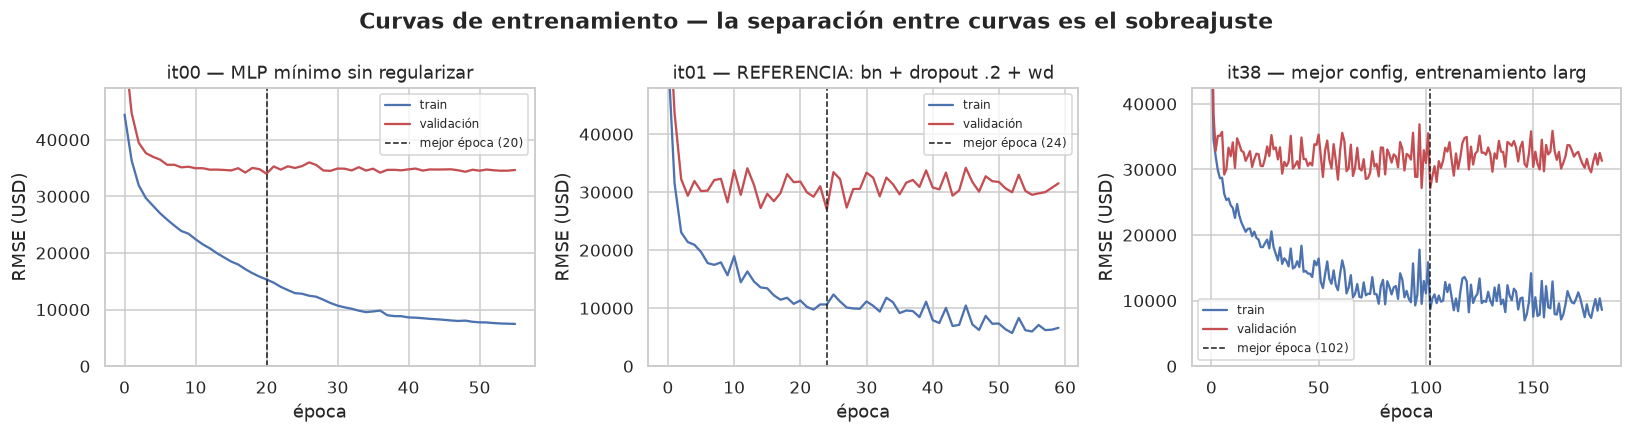

In [20]:
claves = ["it00", "it01", mejor_id]
claves = list(dict.fromkeys([c for c in claves if c in resultados and resultados[c].historias]))

fig, axes = plt.subplots(1, len(claves), figsize=(5 * len(claves), 4), squeeze=False)
for ax, cid in zip(axes[0], claves):
    h = resultados[cid].historias[0]
    ax.plot(h.train_rmse, label="train", color="#4C72B0")
    ax.plot(h.val_rmse, label="validación", color="#C44E52")
    ax.axvline(h.best_epoch, ls="--", color="k", lw=1, label=f"mejor época ({h.best_epoch})")
    ax.set_title(f"{cid} — {resultados[cid].descripcion[:32]}")
    ax.set_xlabel("época"); ax.set_ylabel("RMSE (USD)")
    ax.set_ylim(0, min(90000, max(h.val_rmse[1:]) * 1.1))
    ax.legend(fontsize=8)
fig.suptitle("Curvas de entrenamiento — la separación entre curvas es el sobreajuste",
             fontweight="bold")
fig.tight_layout(); fig.savefig(FIGURES / "16_curvas_entrenamiento.png"); plt.show()

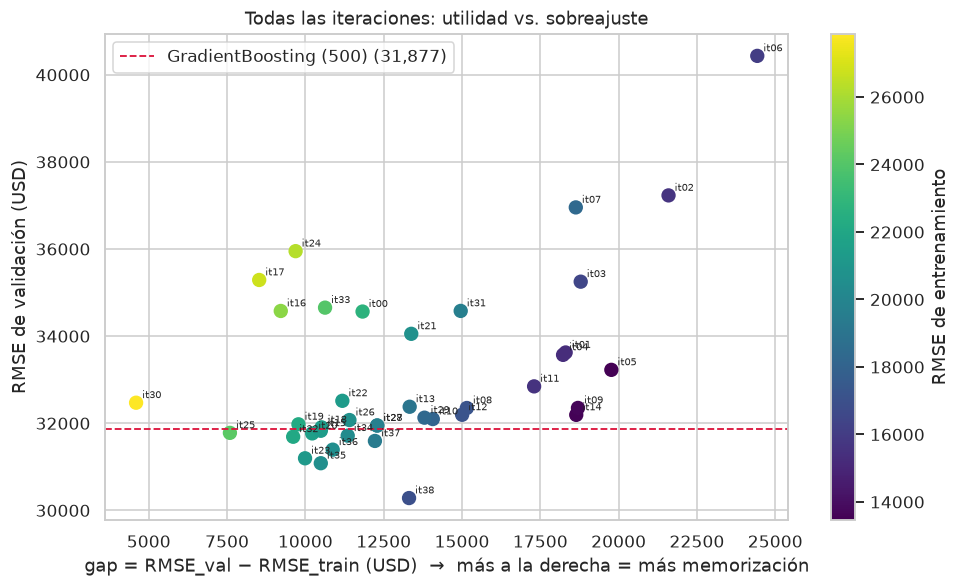

Correlación entre gap y RMSE de validación: 0.51
Las iteraciones con menor gap no son automáticamente las mejores: regularizar de más
cierra la brecha subiendo el error de entrenamiento sin bajar el de validación.


In [21]:
fig, ax = plt.subplots(figsize=(9, 5.5))
t = final.copy()
sc = ax.scatter(t["gap"], t["val_rmse"], c=t["train_rmse"], cmap="viridis", s=70)
for _, row in t.iterrows():
    ax.annotate(row["id"], (row["gap"], row["val_rmse"]), fontsize=6.5,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(OBJETIVO, ls="--", color="crimson", lw=1.2, label=f"{MEJOR_BASELINE} ({OBJETIVO:,.0f})")
ax.set_xlabel("gap = RMSE_val − RMSE_train (USD)  →  más a la derecha = más memorización")
ax.set_ylabel("RMSE de validación (USD)")
ax.set_title("Todas las iteraciones: utilidad vs. sobreajuste")
plt.colorbar(sc, label="RMSE de entrenamiento")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "17_iteraciones_gap.png"); plt.show()

corr = t["gap"].corr(t["val_rmse"])
print(f"Correlación entre gap y RMSE de validación: {corr:.2f}")
print("Las iteraciones con menor gap no son automáticamente las mejores: regularizar de más")
print("cierra la brecha subiendo el error de entrenamiento sin bajar el de validación.")

In [22]:
# Tabla completa para el trabajo escrito (§2.3)
final.to_csv(ROOT / "reports" / "tabla_iteraciones.csv", index=False)
print(f"{len(final)} iteraciones registradas en reports/tabla_iteraciones.csv")
final

39 iteraciones registradas en reports/tabla_iteraciones.csv


,id,descripcion,train_rmse,val_rmse,val_std,gap,gap_ratio,epocas,n_features,vs. GradientBoosting
0,it38,"mejor config, entrenamiento largo",16972.9,30282.1,2951.9,13309.2,0.784,81.9,217,-1595.0
1,it35,scheduler cosine,20589.8,31081.9,2621.2,10492.2,0.510,38.7,217,-796.0
2,it23,sin agrupar categorías raras,21205.8,31195.0,2547.2,9989.1,0.471,43.3,217,-682.0
3,it36,activación gelu,20520.6,31392.8,2653.7,10872.2,0.530,28.9,217,-485.0
4,it37,activación silu,19373.3,31593.3,3014.5,12220.0,0.631,37.6,217,-284.0
5,it32,batch_size=128,22079.6,31689.5,2313.7,9609.9,0.435,42.0,217,-188.0
6,it34,lr=0.003,20362.9,31714.3,4498.8,11351.4,0.557,30.6,217,-163.0
7,it20,weight_decay=0.01,21548.2,31766.3,3545.8,10218.1,0.474,34.3,202,-111.0
8,it25,agrupación de raras más agresiva,24187.9,31778.8,3394.1,7590.9,0.314,31.5,168,-99.0
9,it15,dropout=0.35,21334.0,31827.0,3480.8,10493.0,0.492,37.4,202,-50.0
